# Electio-Analytics — Modele predictif des tendances electorales
## MSPR TPRE813 — Big Data & Analyse de donnees — EPSI Toulouse 2025/2026

**Perimetre :** France, niveau departement (94 entites apres merge)  
**Donnees :** SQLite `db/mspr.db` — election 2022 T1, chomage, criminalite, entreprises  
**Modeles :** Regression Ridge · Random Forest · XGBoost  
**Objectif :** Predire le % de voix par candidat pour T+1 / T+2 / T+3 (2023, 2024, 2025)

---
**Table des matieres**
1. Imports et configuration
2. Chargement et exploration (EDA)
3. Pipeline ETL — construction du dataset
4. Analyse exploratoire et correlations
5. Entrainement des modeles et mesure de l'accuracy
6. Generation des predictions T+1 / T+2 / T+3
7. Visualisation 1 — Courbe temporelle des scenarios
8. Visualisation 2 — Heatmap des scores predits 2025
9. Visualisation 3 — Diagramme de probabilite (incertitude)
10. Conclusion et reponses aux questions du sujet

## 1. Imports et configuration

In [1]:
import sqlite3, os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

# Style graphique global
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 13, 'axes.labelsize': 11,
})
sns.set_theme(style='whitegrid')

DB_PATH = os.path.normpath(os.path.join(os.path.abspath(''), '..', '..', 'db', 'mspr.db'))
conn    = sqlite3.connect(DB_PATH)
print('DB connectee:', DB_PATH)
print('Tables:', [r[0] for r in conn.execute(
    "SELECT name FROM sqlite_master WHERE type='table'").fetchall()])

DB connectee: D:\EPSI\I1\MSPR\mspr_tpre813_election\db\mspr.db
Tables: ['departement', 'chomage', 'demographie', 'criminalite', 'election', 'entreprises']


## 2. Chargement et exploration des donnees (EDA)

In [2]:
df_dept = pd.read_sql('SELECT * FROM departement', conn, dtype={'code_dept':str})
df_chom = pd.read_sql('SELECT * FROM chomage',     conn, dtype={'code_dept':str})
df_crim = pd.read_sql('SELECT * FROM criminalite', conn, dtype={'code_dept':str})
df_entr = pd.read_sql('SELECT * FROM entreprises', conn, dtype={'code_dept':str})
df_elec = pd.read_sql('SELECT * FROM election',    conn, dtype={'code_dept':str})

print('Table         Lignes  Colonnes')
for n,d in [('departement',df_dept),('chomage',df_chom),('criminalite',df_crim),
            ('entreprises',df_entr),('election',df_elec)]:
    print(f'  {n:<15} {d.shape[0]:>6}  {d.shape[1]:>6}')

Table         Lignes  Colonnes
  departement        101       2
  chomage           4136       6
  criminalite      15360       8
  entreprises       1248      52
  election          1152      21


In [3]:
df_elec.head(6)

,code_dept,inscrits,abstentions,pct_abs_ins,votants,pct_vot_ins,blancs,pct_blancs_ins,pct_blancs_vot,nuls,...,pct_nuls_vot,exprimes,pct_exp_ins,pct_exp_vot,sexe,nom,prenom,voix,pct_voix_ins,pct_voix_exp
0,01,438109,97541,22.26,340568,77.74,5642,1.29,1.66,1902,...,0.56,333024,76.01,97.78,F,ARTHAUD,Nathalie,1658,0.38,0.50
1,01,438109,97541,22.26,340568,77.74,5642,1.29,1.66,1902,...,0.56,333024,76.01,97.78,M,ROUSSEL,Fabien,5938,1.36,1.78
2,01,438109,97541,22.26,340568,77.74,5642,1.29,1.66,1902,...,0.56,333024,76.01,97.78,M,MACRON,Emmanuel,92206,21.05,27.69
3,01,438109,97541,22.26,340568,77.74,5642,1.29,1.66,1902,...,0.56,333024,76.01,97.78,M,LASSALLE,Jean,10876,2.48,3.27
4,01,438109,97541,22.26,340568,77.74,5642,1.29,1.66,1902,...,0.56,333024,76.01,97.78,F,LE PEN,Marine,86755,19.80,26.05
5,01,438109,97541,22.26,340568,77.74,5642,1.29,1.66,1902,...,0.56,333024,76.01,97.78,M,ZEMMOUR,Éric,27530,6.28,8.27


### 2.1 Distribution des scores par candidat — boxplot

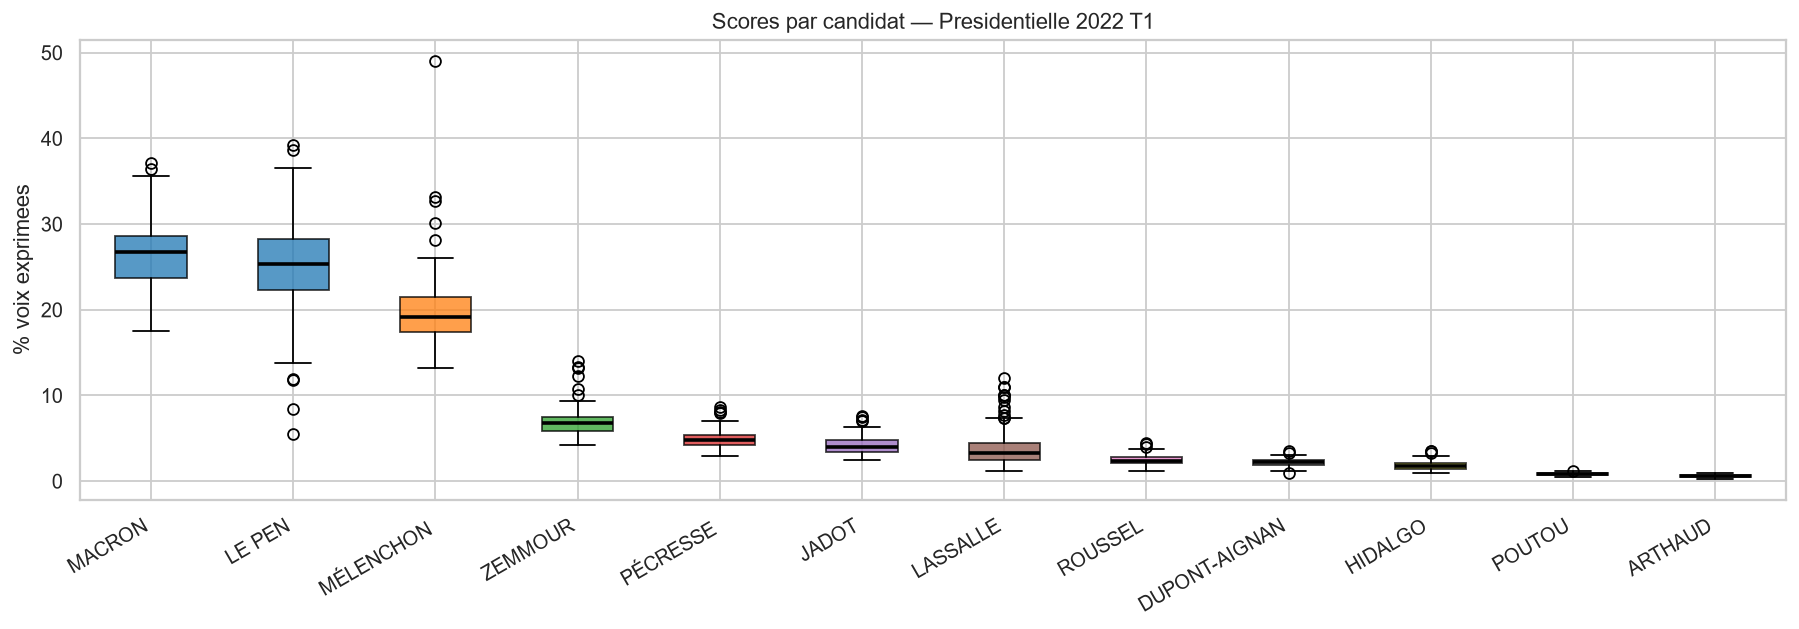

In [4]:
order_c = df_elec.groupby('nom')['pct_voix_exp'].mean().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(14, 5))
data_box = [df_elec[df_elec['nom']==c]['pct_voix_exp'].values for c in order_c]
bp = ax.boxplot(data_box, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
palette = plt.cm.tab10(np.linspace(0,1,len(order_c)))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_xticklabels(order_c, rotation=30, ha='right')
ax.set_ylabel('% voix exprimees'); ax.set_title('Scores par candidat — Presidentielle 2022 T1')
plt.tight_layout(); plt.savefig('eda_boxplot_scores.png'); plt.show()

### 2.2 Taux de chomage moyen par departement (2016-2021)

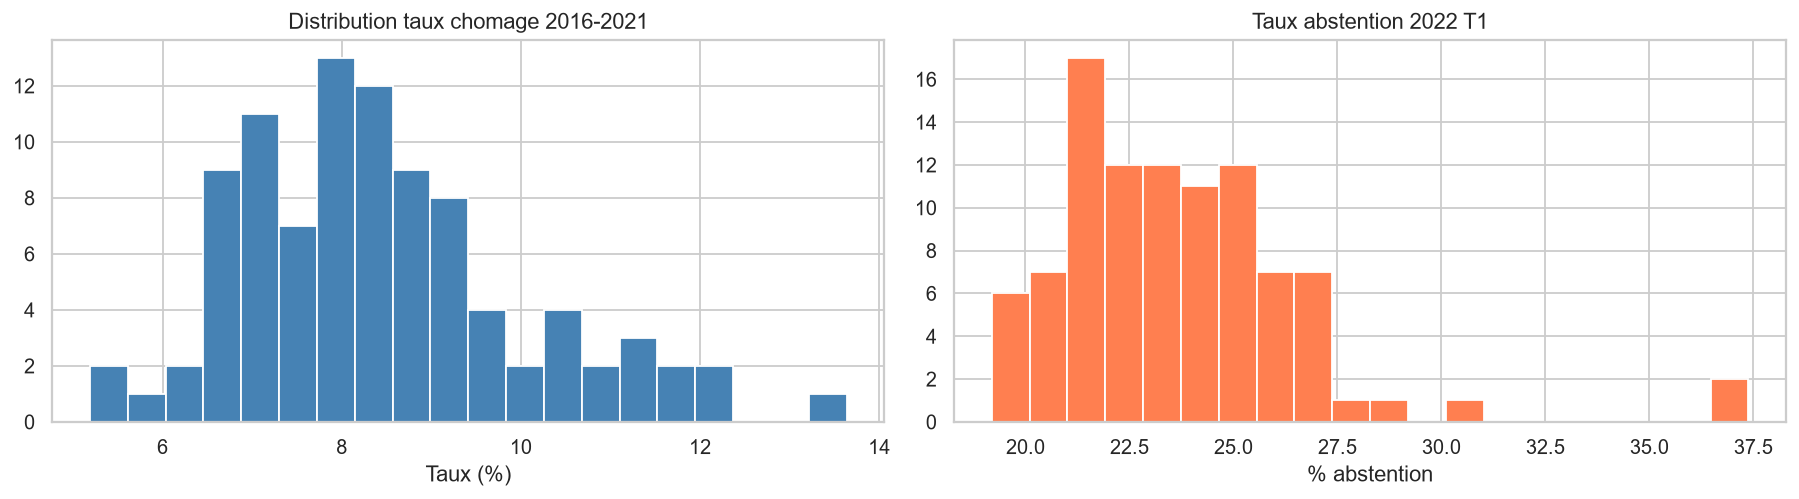

In [5]:
chom_moy = (df_chom[df_chom['annee'].between(2016,2021)]
            .groupby('code_dept')['taux_chomage_moyen'].mean())
fig, axes = plt.subplots(1,2, figsize=(14,4))
axes[0].hist(chom_moy, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution taux chomage 2016-2021'); axes[0].set_xlabel('Taux (%)')
abs_moy = df_elec.groupby('code_dept')['pct_abs_ins'].first()
axes[1].hist(abs_moy, bins=20, color='coral', edgecolor='white')
axes[1].set_title('Taux abstention 2022 T1'); axes[1].set_xlabel('% abstention')
plt.tight_layout(); plt.savefig('eda_distributions.png'); plt.show()

## 3. Pipeline ETL — Construction du dataset ML

```
[chomage]     --+
[criminalite] --+-- pivot / agregation --> [features_socioeco] --+
[entreprises] --+                                                 +--> [dataset_ml] --> MODELE
[election]    -------------------------------- labels (% voix) ---+
```

- **Features** : moyennes departementales 2016–2021 (chomage, 7 indicateurs criminalite, entreprises)
- **Labels** : % voix exprimees par candidat, election presidentielle 2022 T1
- **Predictions** : on reinjecte les features des annees 2023, 2024, 2025 dans le modele entraine

In [6]:
CRIM_IND = ['cambriolages','homicides','trafic_stupefiants',
            'violences_hors_famille','violences_sexuelles',
            'vols_sans_violence','vols_avec_armes']

def get_chomage(yr):
    return (df_chom[df_chom['annee']==yr][['code_dept','taux_chomage_moyen']]
            .rename(columns={'taux_chomage_moyen':'chomage_moyen'}))

def get_criminalite(yr):
    sub = df_crim[(df_crim['annee']==yr) & df_crim['indicateur_clean'].isin(CRIM_IND)]
    piv = sub.pivot_table(index='code_dept', columns='indicateur_clean',
                          values='taux_pour_mille', aggfunc='mean').reset_index()
    piv.columns = ['code_dept']+['crim_'+c for c in piv.columns[1:]]
    return piv

def get_entreprises(yr):
    return (df_entr[df_entr['annee']==yr][['code_dept','bure__total__total']]
            .rename(columns={'bure__total__total':'nb_entreprises'}))

def build_features(yr):
    return (get_chomage(yr)
            .merge(get_criminalite(yr), on='code_dept', how='inner')
            .merge(get_entreprises(yr), on='code_dept', how='inner'))

# Agregation des features 2016-2021 par departement
frames = [build_features(yr) for yr in range(2016, 2022)]
df_all = pd.concat(frames, ignore_index=True)
FEAT_COLS = [c for c in df_all.columns if c != 'code_dept']
df_feat = df_all.groupby('code_dept')[FEAT_COLS].mean().reset_index()

print(f'Dataset features : {df_feat.shape[0]} departements x {len(FEAT_COLS)} variables')
print('Variables :', FEAT_COLS)

Dataset features : 94 departements x 9 variables
Variables : ['chomage_moyen', 'crim_cambriolages', 'crim_homicides', 'crim_trafic_stupefiants', 'crim_violences_hors_famille', 'crim_violences_sexuelles', 'crim_vols_avec_armes', 'crim_vols_sans_violence', 'nb_entreprises']


In [7]:
# Candidats principaux (>80% des voix)
CANDS = ['MACRON','LE PEN','MELENCHON','ZEMMOUR']
NOM_DB = {'MACRON':'MACRON','LE PEN':'LE PEN',
           'MELENCHON':'M\u00c9LENCHON','ZEMMOUR':'ZEMMOUR'}
COLORS = {'MACRON':'#1A73E8','LE PEN':'#C0392B',
           'MELENCHON':'#8E44AD','ZEMMOUR':'#E67E22'}

datasets = {}
for c in CANDS:
    labels = (df_elec[df_elec['nom']==NOM_DB[c]][['code_dept','pct_voix_exp']]
              .rename(columns={'pct_voix_exp':'y'}))
    df_ml = df_feat.merge(labels, on='code_dept', how='inner').dropna()
    datasets[c] = df_ml
    print(f'{c:<12}: {len(df_ml)} obs | moy={df_ml.y.mean():.1f}% | std={df_ml.y.std():.1f}%')

MACRON      : 94 obs | moy=26.9% | std=3.9%
LE PEN      : 94 obs | moy=25.1% | std=6.0%
MELENCHON   : 94 obs | moy=20.2% | std=4.8%
ZEMMOUR     : 94 obs | moy=6.9% | std=1.6%


## 4. Analyse exploratoire — correlations

### 4.1 Heatmap de correlations (features x score LE PEN)

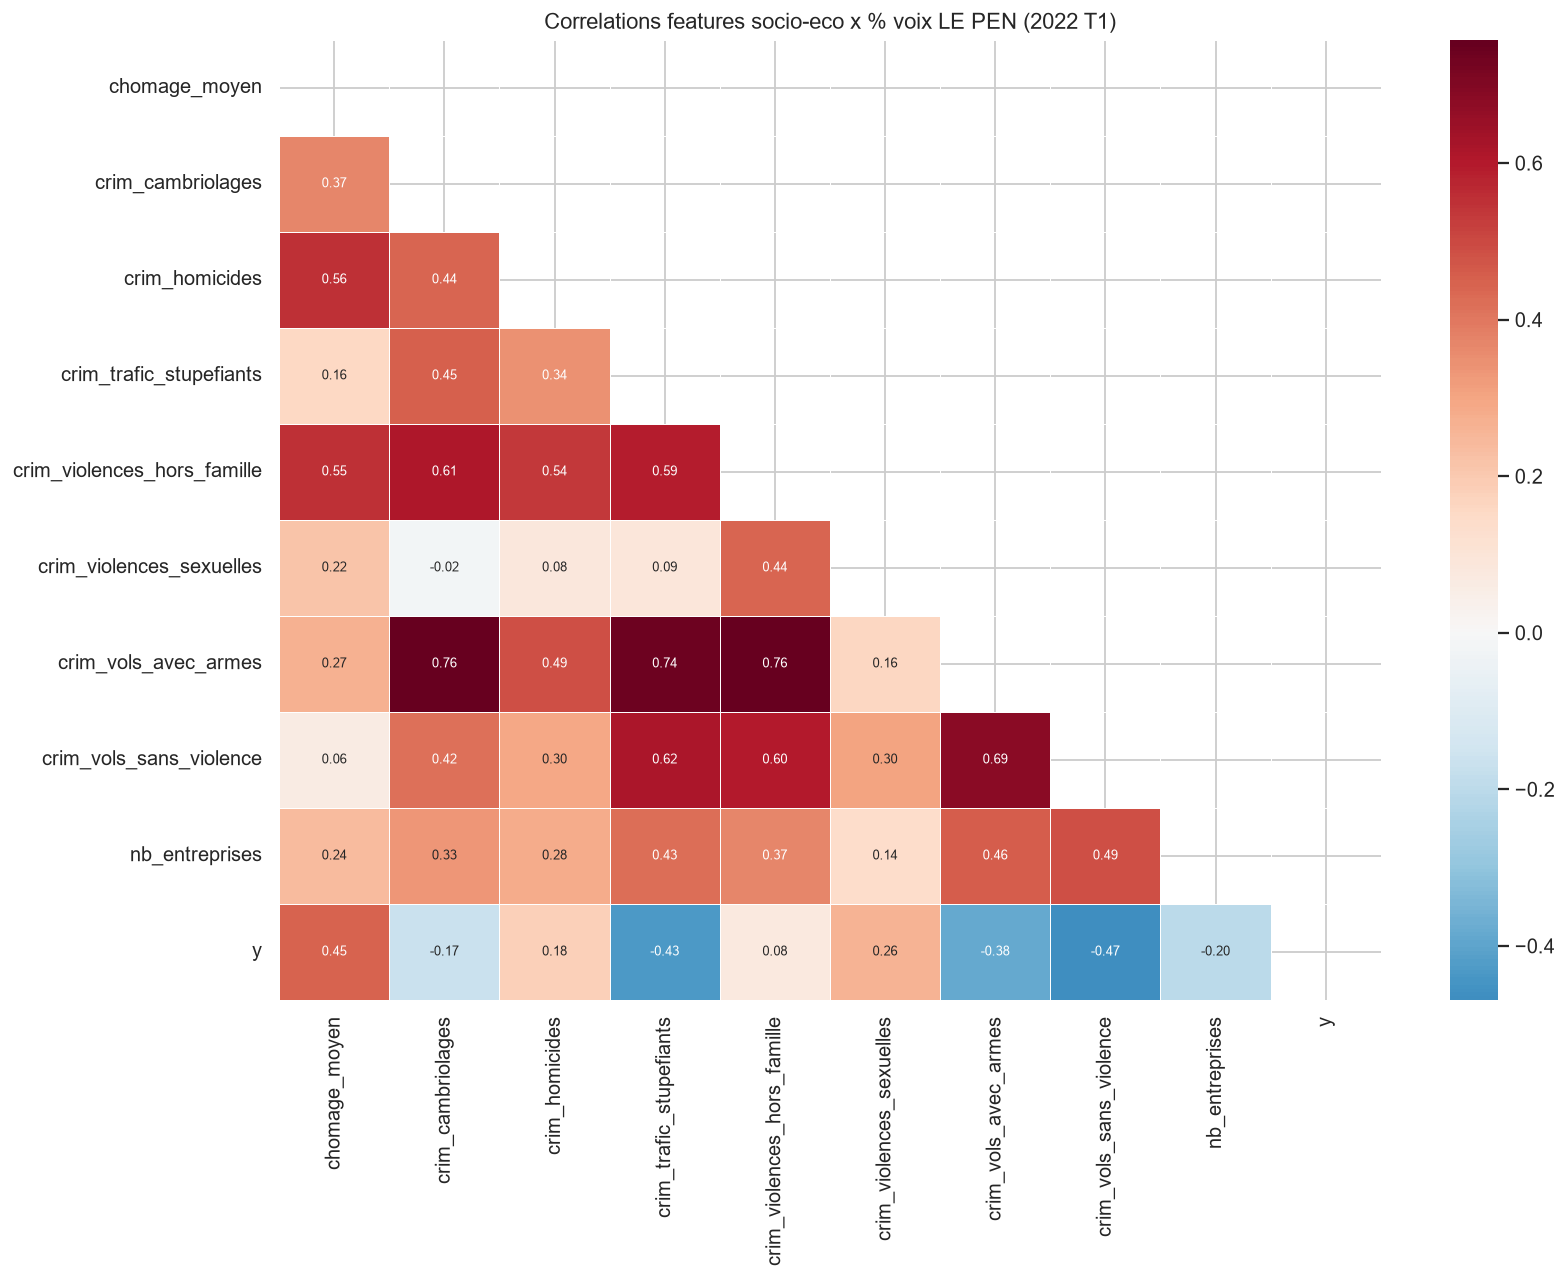

In [8]:
df_c = datasets['LE PEN'].copy()
fig, ax = plt.subplots(figsize=(13,10))
corr = df_c[FEAT_COLS+['y']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=.5, ax=ax, annot_kws={'size':7})
ax.set_title('Correlations features socio-eco x % voix LE PEN (2022 T1)')
plt.tight_layout(); plt.savefig('corr_heatmap_lepen.png'); plt.show()

### 4.2 Correlations par candidat + scatter meilleure feature

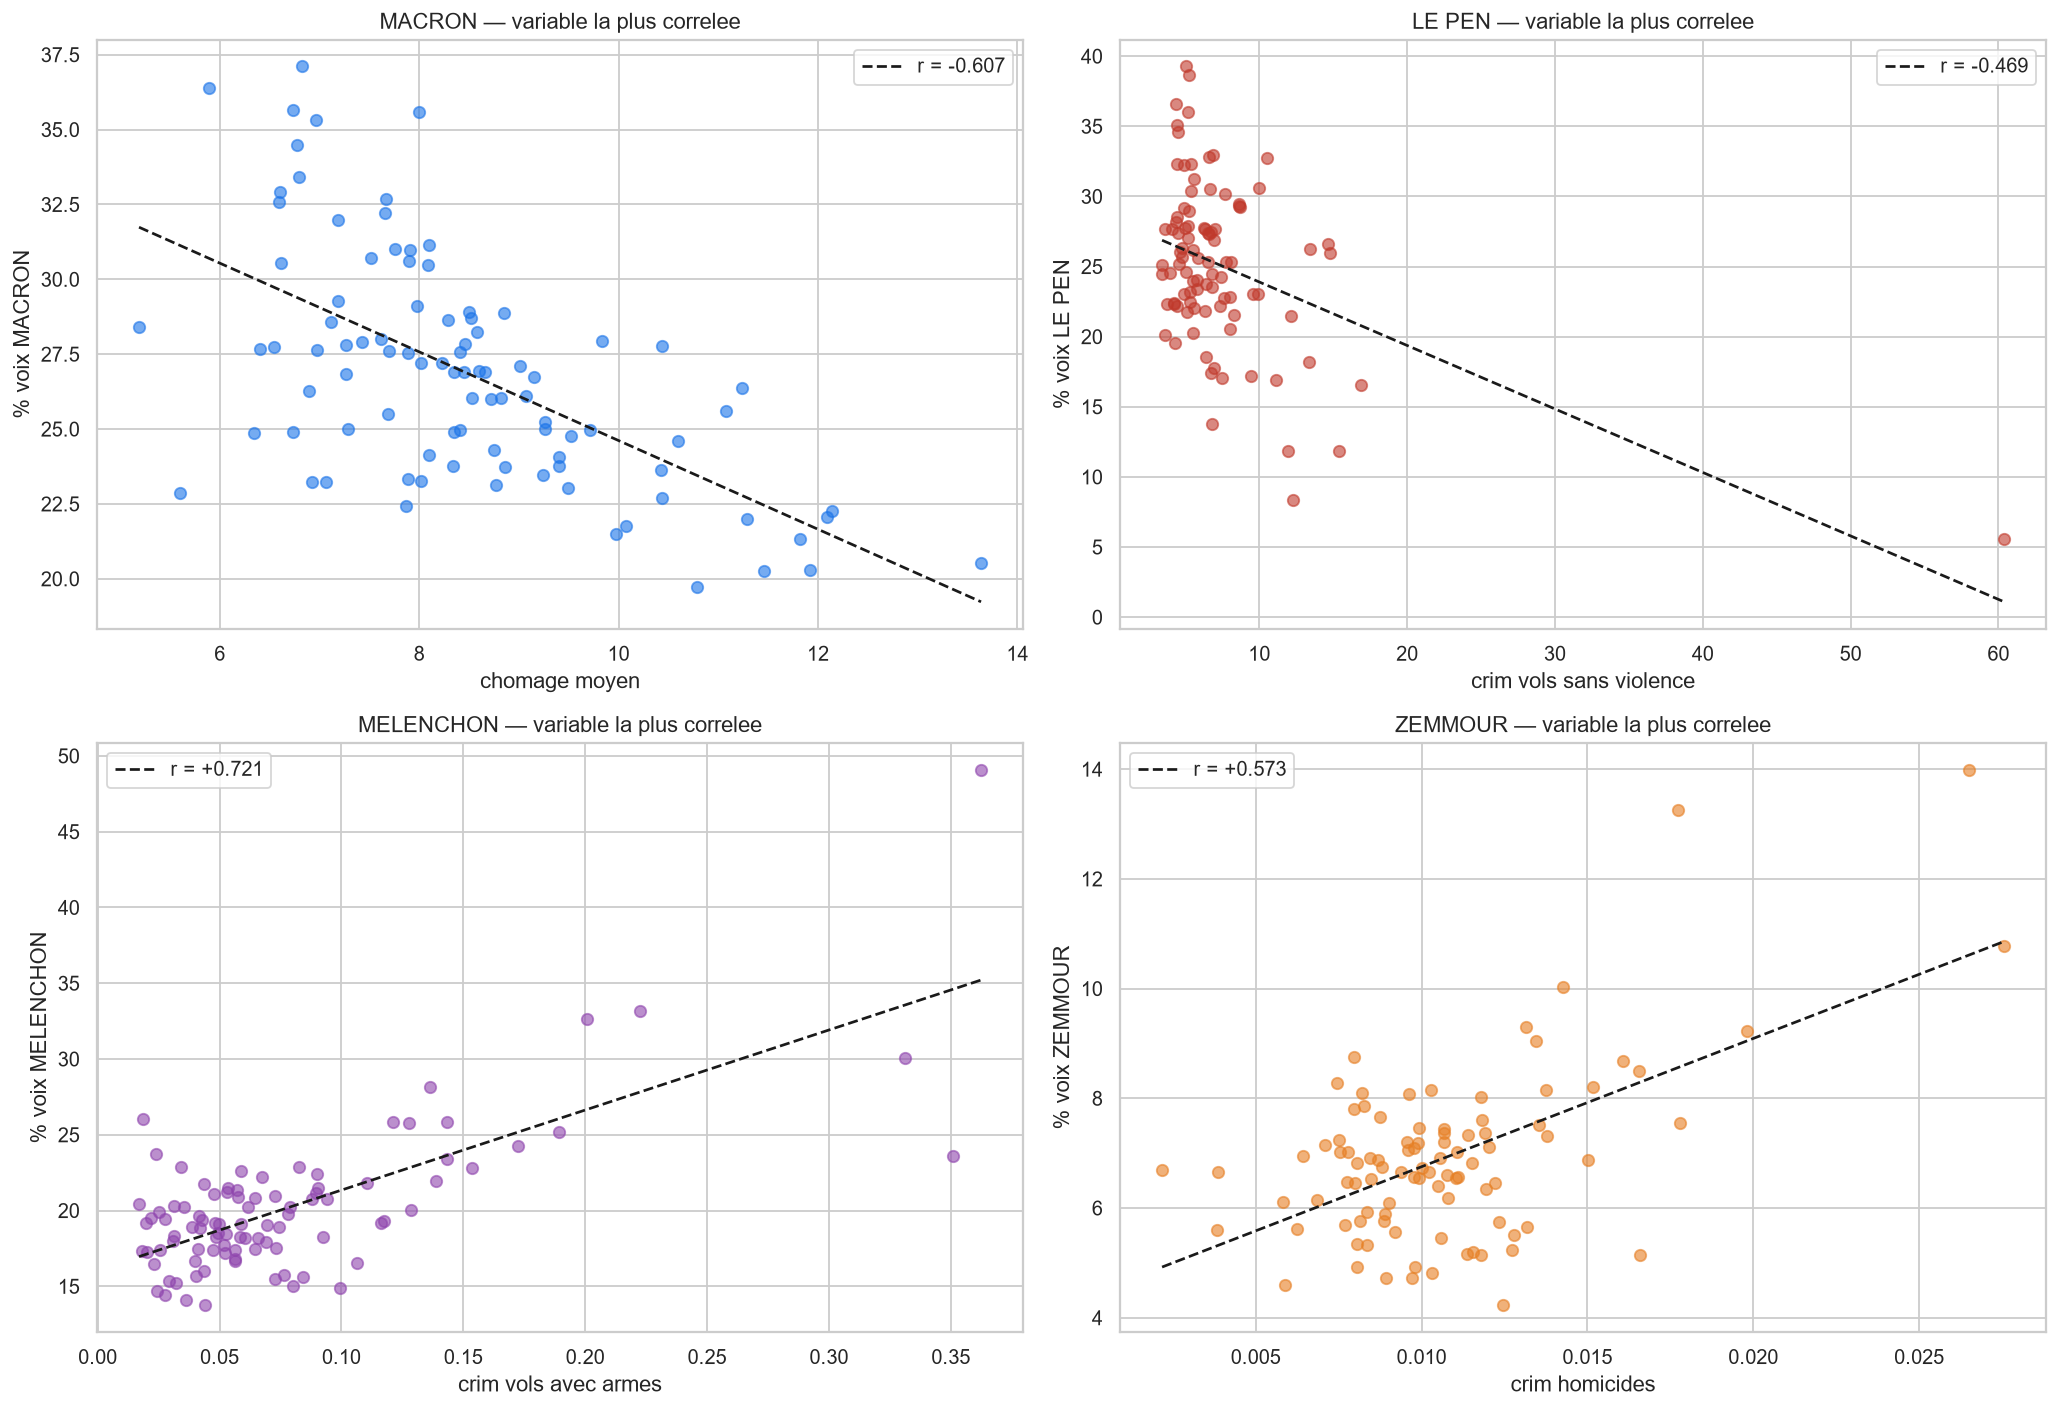

In [9]:
fig, axes = plt.subplots(2,2, figsize=(16,11)); axes=axes.flatten()
for i,c in enumerate(CANDS):
    df_c = datasets[c]
    corrs = df_c[FEAT_COLS].corrwith(df_c['y'])
    best  = corrs.abs().idxmax()
    ax    = axes[i]
    ax.scatter(df_c[best], df_c['y'], alpha=.6, s=40, color=COLORS[c])
    z = np.polyfit(df_c[best], df_c['y'], 1)
    xl = np.linspace(df_c[best].min(), df_c[best].max(), 100)
    ax.plot(xl, np.poly1d(z)(xl), 'k--', lw=1.5,
            label=f'r = {corrs[best]:+.3f}')
    ax.set_xlabel(best.replace('_',' '))
    ax.set_ylabel(f'% voix {c}')
    ax.set_title(f'{c} — variable la plus correlee')
    ax.legend()
plt.tight_layout(); plt.savefig('corr_scatter.png'); plt.show()

## 5. Entrainement des modeles et mesure de l'accuracy

**Modeles testes :** Regression Ridge · Random Forest (200 arbres) · XGBoost (200 estimateurs)  
**Validation :** Cross-validation 5-fold sur les 94 departements  
**Metriques retenues :**
- **R²** (coefficient de determination) : proportion de variance expliquee. 0 = nul, 1 = parfait. Seuil acceptable : 0.60
- **MAE** (Mean Absolute Error) : erreur en points de %, directement lisible par le client
- **RMSE** : racine de l'erreur quadratique moyenne, penalise davantage les gros ecarts

In [10]:
MODELES = {
    'Ridge':        Ridge(alpha=1.0),
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=6,
                                          random_state=42, n_jobs=-1),
    'XGBoost':      XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                                 subsample=0.8, random_state=42, verbosity=0),
}
CV = KFold(n_splits=5, shuffle=True, random_state=42)
sc = StandardScaler()

rows        = []
best_models = {}
rf_models   = {}   # RF entraine sur tout le dataset (pour diagramme proba)

for cand in CANDS:
    X_raw = datasets[cand][FEAT_COLS].values
    y     = datasets[cand]['y'].values
    X_sc  = sc.fit_transform(X_raw)
    best_r2 = -np.inf

    for nom, modele in MODELES.items():
        Xin = X_sc if nom == 'Ridge' else X_raw

        r2_cv  = cross_val_score(modele, Xin, y, cv=CV, scoring='r2')
        mae_cv = cross_val_score(modele, Xin, y, cv=CV, scoring='neg_mean_absolute_error')
        mse_cv = cross_val_score(modele, Xin, y, cv=CV, scoring='neg_mean_squared_error')

        rows.append(dict(
            Candidat=cand, Modele=nom,
            R2_mean=r2_cv.mean(), R2_std=r2_cv.std(),
            MAE_mean=(-mae_cv).mean(), MAE_std=(-mae_cv).std(),
            RMSE_mean=np.sqrt((-mse_cv).mean()),
        ))

        # Fit final sur tout le dataset
        m = type(modele)(**modele.get_params())
        m.fit(Xin, y)

        # Stocker le RF pour importance + diagramme proba
        if nom == 'RandomForest':
            rf_models[cand] = m

        if r2_cv.mean() > best_r2:
            best_r2 = r2_cv.mean()
            best_models[cand] = {'nom':nom, 'modele':m,
                                 'scaler': sc if nom=='Ridge' else None,
                                 'r2': r2_cv.mean(), 'mae': (-mae_cv).mean(),
                                 'rmse': np.sqrt((-mse_cv).mean())}

df_res = pd.DataFrame(rows)
print(df_res.to_string(index=False, float_format='{:.3f}'.format))

 Candidat       Modele  R2_mean  R2_std  MAE_mean  MAE_std  RMSE_mean
   MACRON        Ridge    0.013   0.468     2.653    0.322      3.798
   MACRON RandomForest    0.366   0.196     2.331    0.241      2.932
   MACRON      XGBoost    0.314   0.247     2.348    0.297      3.029
   LE PEN        Ridge    0.321   0.532     3.226    0.915      5.258
   LE PEN RandomForest    0.452   0.134     3.278    0.403      4.365
   LE PEN      XGBoost    0.539   0.187     2.993    0.454      3.920
MELENCHON        Ridge   -0.074   0.590     2.539    0.614      4.004
MELENCHON RandomForest    0.189   0.528     2.449    0.572      3.636
MELENCHON      XGBoost    0.115   0.658     2.390    0.587      3.689
  ZEMMOUR        Ridge    0.312   0.243     0.924    0.125      1.150
  ZEMMOUR RandomForest    0.291   0.365     0.869    0.145      1.186
  ZEMMOUR      XGBoost    0.048   0.790     0.900    0.076      1.251


### 5.1 Tableau recapitulatif de l'accuracy par modele et par candidat

In [11]:
print(f'\n{"=" * 68}')
print(f'{"CANDIDAT":<12} {"MEILLEUR MODELE":<16} {"R2":>7} {"MAE (pts%)": >12} {"RMSE":>8}')
print(f'{"="*68}')
for c in CANDS:
    info = best_models[c]
    print(f'{c:<12} {info["nom"]:<16} {info["r2"]:>7.3f} {info["mae"]:>12.2f} {info["rmse"]:>8.2f}')
print(f'{"="*68}')
print('\nCriteres de validation : R2 > 0.40 (challenge sur 1 seule election), MAE < 3 pts%')


CANDIDAT     MEILLEUR MODELE       R2   MAE (pts%)     RMSE
MACRON       RandomForest       0.366         2.33     2.93
LE PEN       XGBoost            0.539         2.99     3.92
MELENCHON    RandomForest       0.189         2.45     3.64
ZEMMOUR      Ridge              0.312         0.92     1.15

Criteres de validation : R2 > 0.40 (challenge sur 1 seule election), MAE < 3 pts%


### 5.2 Graphique comparaison R2 et MAE des 3 modeles

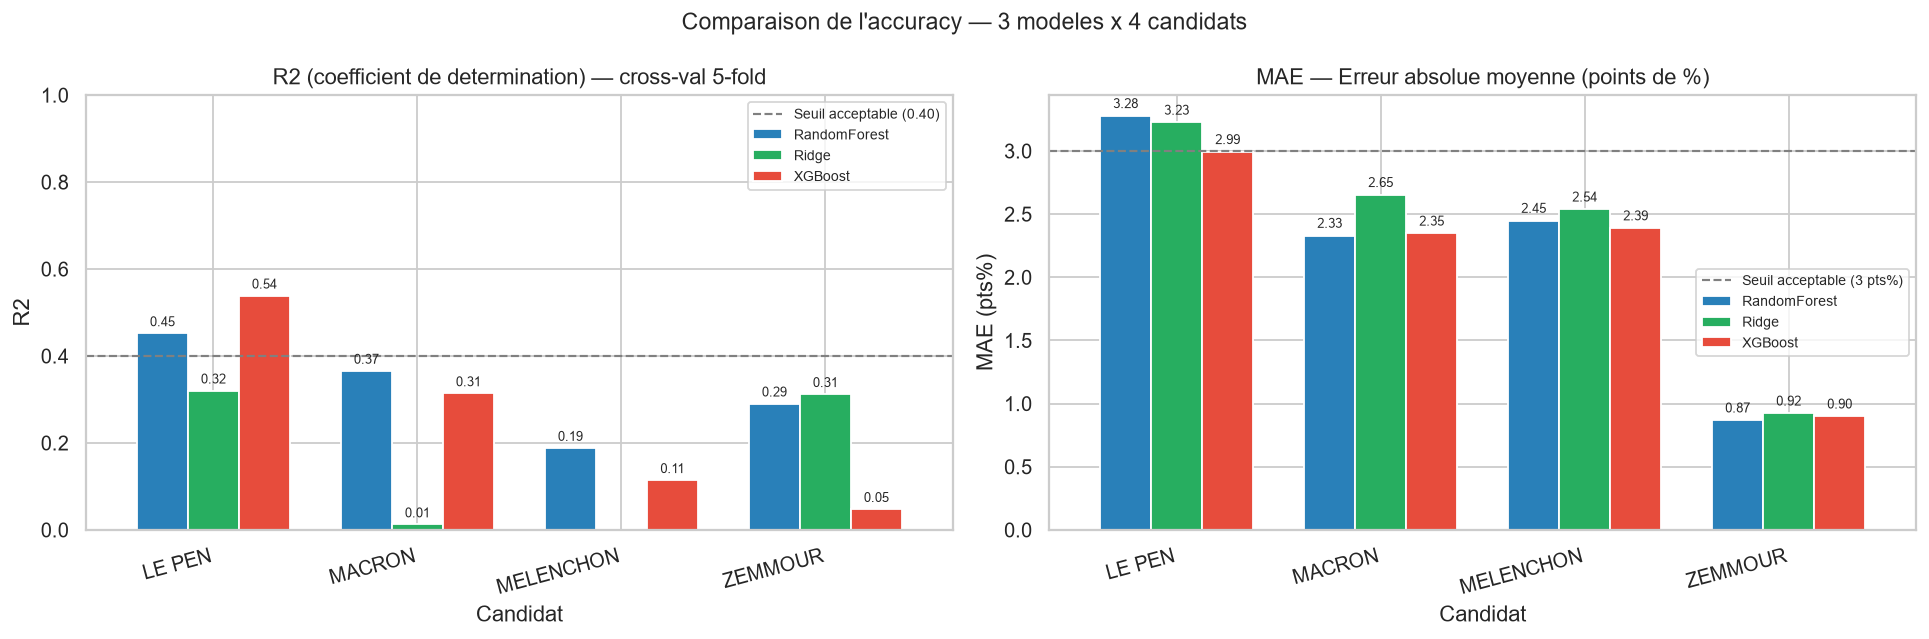

In [12]:
fig, axes = plt.subplots(1,2, figsize=(15,5))

# ── R2 ──
piv_r2 = df_res.pivot(index='Candidat', columns='Modele', values='R2_mean')
piv_r2.plot(kind='bar', ax=axes[0], edgecolor='white', width=.75,
            color=['#2980b9','#27ae60','#e74c3c'])
axes[0].axhline(0.40, color='grey', ls='--', lw=1.2, label='Seuil acceptable (0.40)')
axes[0].set_title('R2 (coefficient de determination) — cross-val 5-fold')
axes[0].set_ylabel('R2'); axes[0].set_ylim(bottom=0, top=1)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')
axes[0].legend(fontsize=8)

# Annotations valeur
for bar in axes[0].patches:
    h = bar.get_height()
    if h > 0:
        axes[0].text(bar.get_x()+bar.get_width()/2, h+.01, f'{h:.2f}',
                     ha='center', va='bottom', fontsize=7)

# ── MAE ──
piv_mae = df_res.pivot(index='Candidat', columns='Modele', values='MAE_mean')
piv_mae.plot(kind='bar', ax=axes[1], edgecolor='white', width=.75,
             color=['#2980b9','#27ae60','#e74c3c'])
axes[1].axhline(3.0, color='grey', ls='--', lw=1.2, label='Seuil acceptable (3 pts%)')
axes[1].set_title('MAE — Erreur absolue moyenne (points de %)')
axes[1].set_ylabel('MAE (pts%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')
axes[1].legend(fontsize=8)

for bar in axes[1].patches:
    h = bar.get_height()
    if h > 0:
        axes[1].text(bar.get_x()+bar.get_width()/2, h+.04, f'{h:.2f}',
                     ha='center', va='bottom', fontsize=7)

plt.suptitle('Comparaison de l\'accuracy — 3 modeles x 4 candidats', fontsize=13)
plt.tight_layout(); plt.savefig('accuracy_comparaison.png'); plt.show()

### 5.3 Importance des features — Random Forest

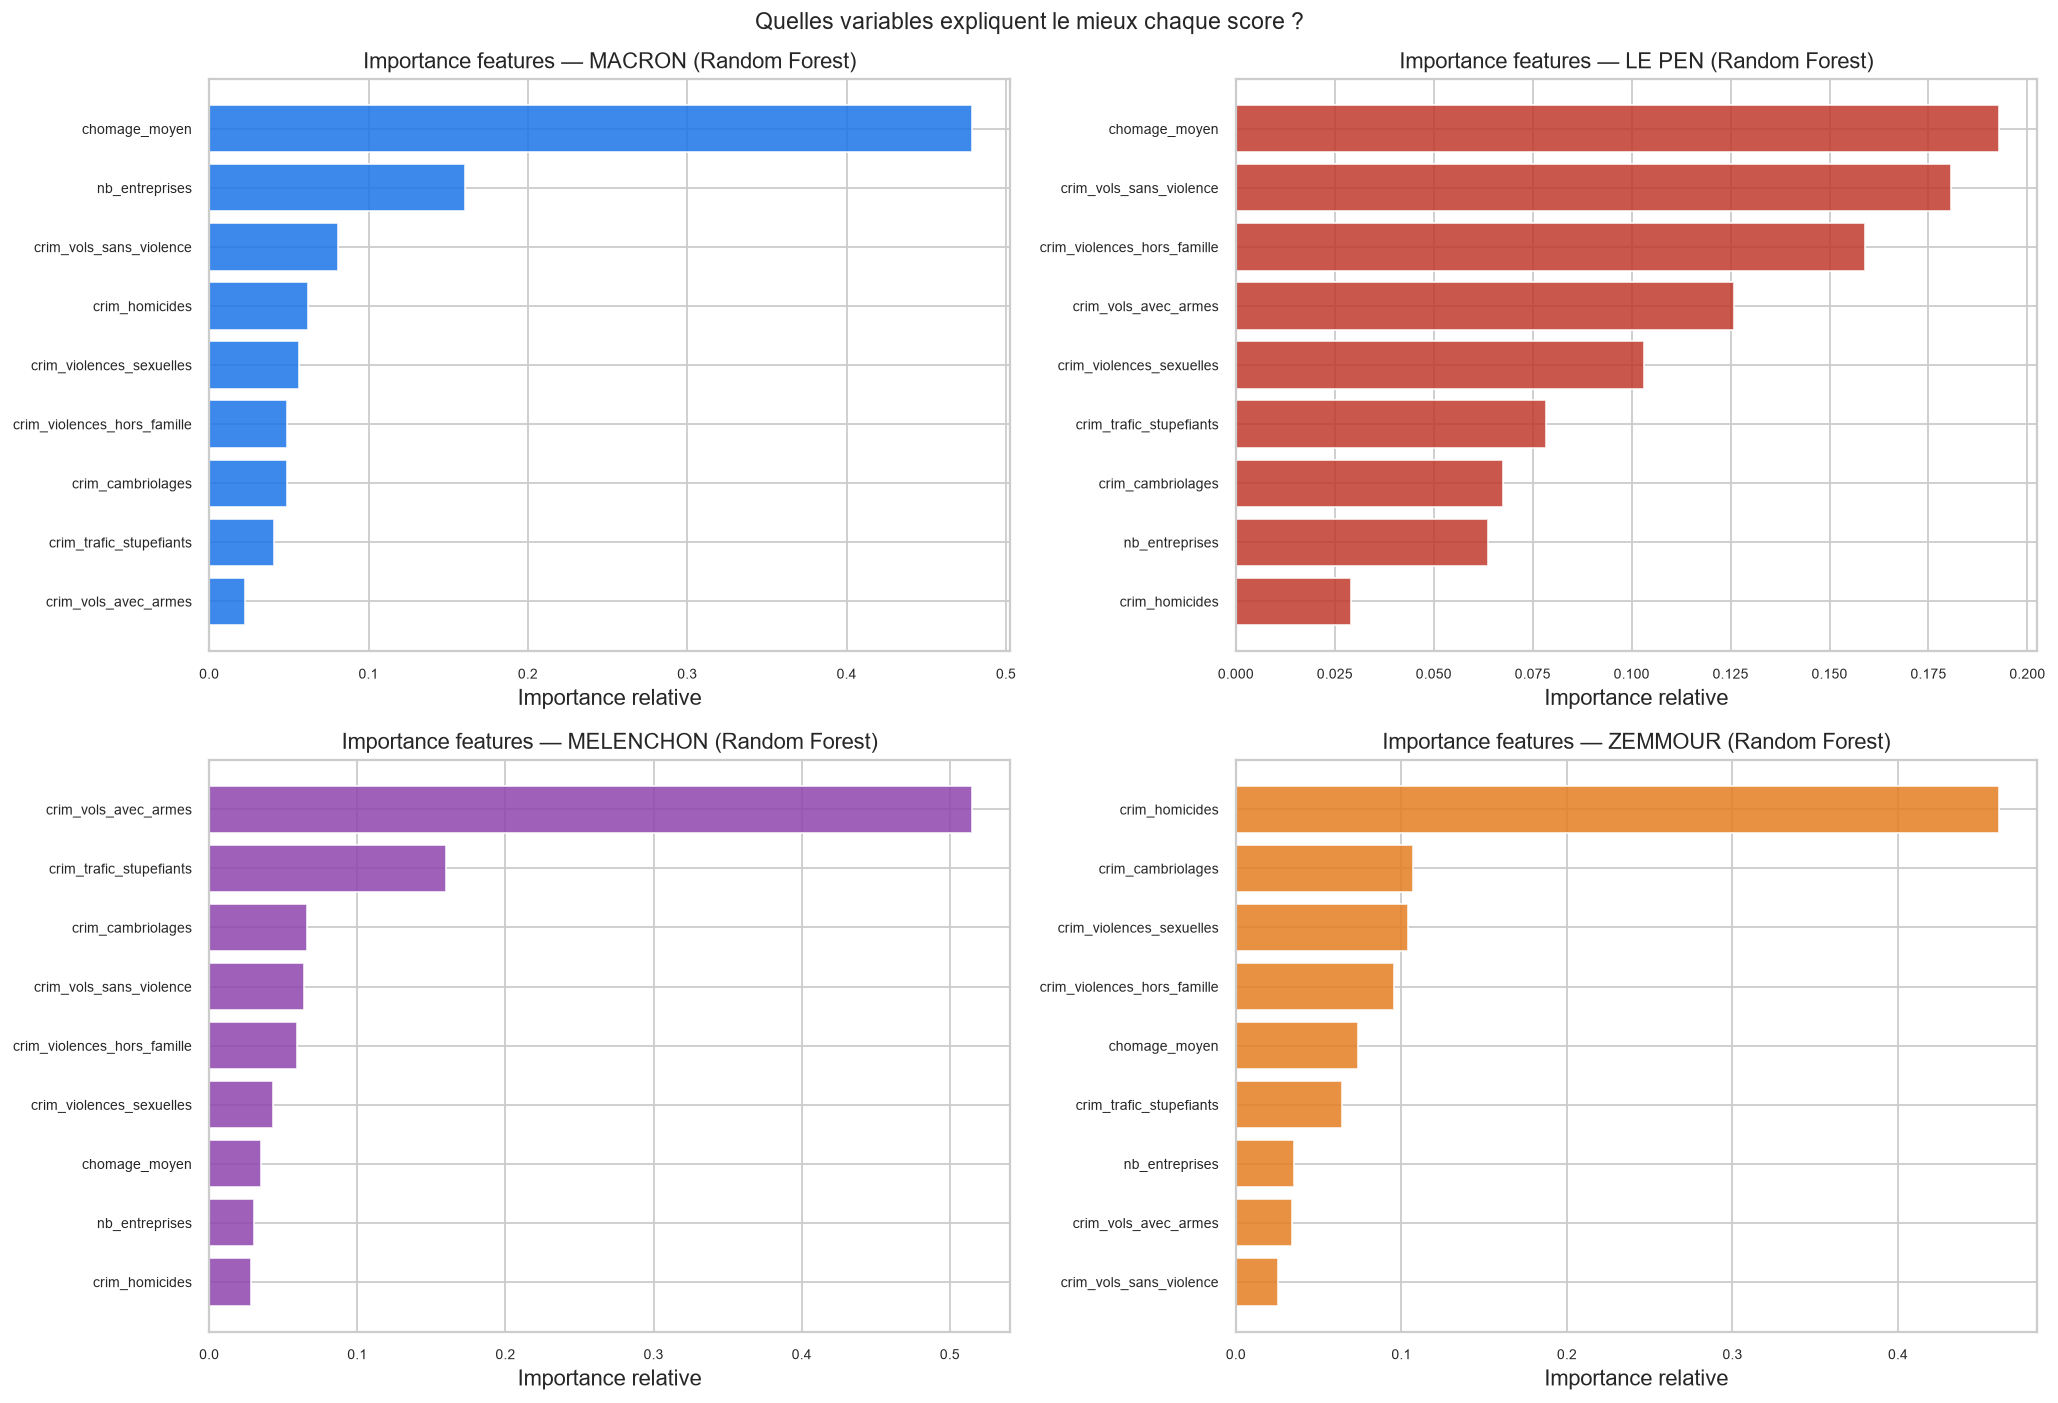

In [13]:
fig, axes = plt.subplots(2,2, figsize=(16,11)); axes=axes.flatten()
for i,c in enumerate(CANDS):
    rf   = rf_models[c]
    imp  = pd.Series(rf.feature_importances_, index=FEAT_COLS).sort_values(ascending=True)
    axes[i].barh(imp.index, imp.values, color=COLORS[c], alpha=.85)
    axes[i].set_title(f'Importance features — {c} (Random Forest)')
    axes[i].set_xlabel('Importance relative')
    axes[i].tick_params(labelsize=8)
plt.suptitle('Quelles variables expliquent le mieux chaque score ?', fontsize=13)
plt.tight_layout(); plt.savefig('rf_feature_importance.png'); plt.show()

## 6. Generation des predictions T+1 / T+2 / T+3

- **T+1 = 2023** : premieres projections apres l'election de reference
- **T+2 = 2024** : scenario a moyen terme
- **T+3 = 2025** : horizon strategique demande par Electio-Analytics

Les features reelles disponibles sont injectees dans le meilleur modele de chaque candidat.  
Pour 2025, les donnees chômage et criminalite sont deja disponibles ; les entreprises utilisent 2024.

In [14]:
ANNEES_PRED = [2023, 2024, 2025]

def features_annee(yr):
    a_ch = yr if yr in df_chom['annee'].values else int(df_chom['annee'].max())
    a_cr = yr if yr in df_crim['annee'].values else int(df_crim['annee'].max())
    a_en = yr if yr in df_entr['annee'].values else int(df_entr['annee'].max())
    df = (get_chomage(a_ch)
          .merge(get_criminalite(a_cr), on='code_dept', how='inner')
          .merge(get_entreprises(a_en), on='code_dept', how='inner'))
    df['annee'] = yr
    print(f'  {yr}: {len(df)} departements | chom={a_ch} crim={a_cr} entr={a_en}')
    return df

print('Construction des features de prediction :')
feat_pred = {yr: features_annee(yr) for yr in ANNEES_PRED}

# Score reel 2022 pour ancrer les courbes
scores_2022 = {c: df_elec[df_elec['nom']==NOM_DB[c]]['pct_voix_exp'].mean() for c in CANDS}

# ── Application des modeles ──────────────────────────────────────────────────
pred_rows = []
for cand in CANDS:
    info = best_models[cand]
    for yr in ANNEES_PRED:
        X = feat_pred[yr][FEAT_COLS].fillna(feat_pred[yr][FEAT_COLS].median()).values
        if info['scaler'] is not None:
            X = info['scaler'].transform(X)
        preds = np.clip(info['modele'].predict(X), 0, 100)
        for k,row in enumerate(feat_pred[yr].itertuples()):
            pred_rows.append({'code_dept':row.code_dept,'annee':yr,
                              'candidat':cand,'pct_predit':preds[k]})

df_pred = pd.DataFrame(pred_rows).merge(df_dept, on='code_dept', how='left')

# Resume national
resume = df_pred.groupby(['candidat','annee'])['pct_predit'].mean().unstack()
print('\nScores nationaux moyens predits (% voix exprimees) :')
print(resume.round(2))

Construction des features de prediction :
  2023: 94 departements | chom=2023 crim=2023 entr=2023
  2024: 94 departements | chom=2024 crim=2024 entr=2024
  2025: 94 departements | chom=2025 crim=2025 entr=2024

Scores nationaux moyens predits (% voix exprimees) :
annee       2023   2024   2025
candidat                      
LE PEN     28.04  28.14  28.79
MACRON     29.23  29.15  28.79
MELENCHON  18.87  18.71  18.70
ZEMMOUR     4.46   3.92   3.47


## 7. Visualisation 1 — Courbe temporelle T / T+1 / T+2 / T+3

La courbe ancre le score **reel 2022** puis trace les predictions a T+1, T+2, T+3.  
L'intervalle de confiance est estime via l'ecart-type des predictions par departement.

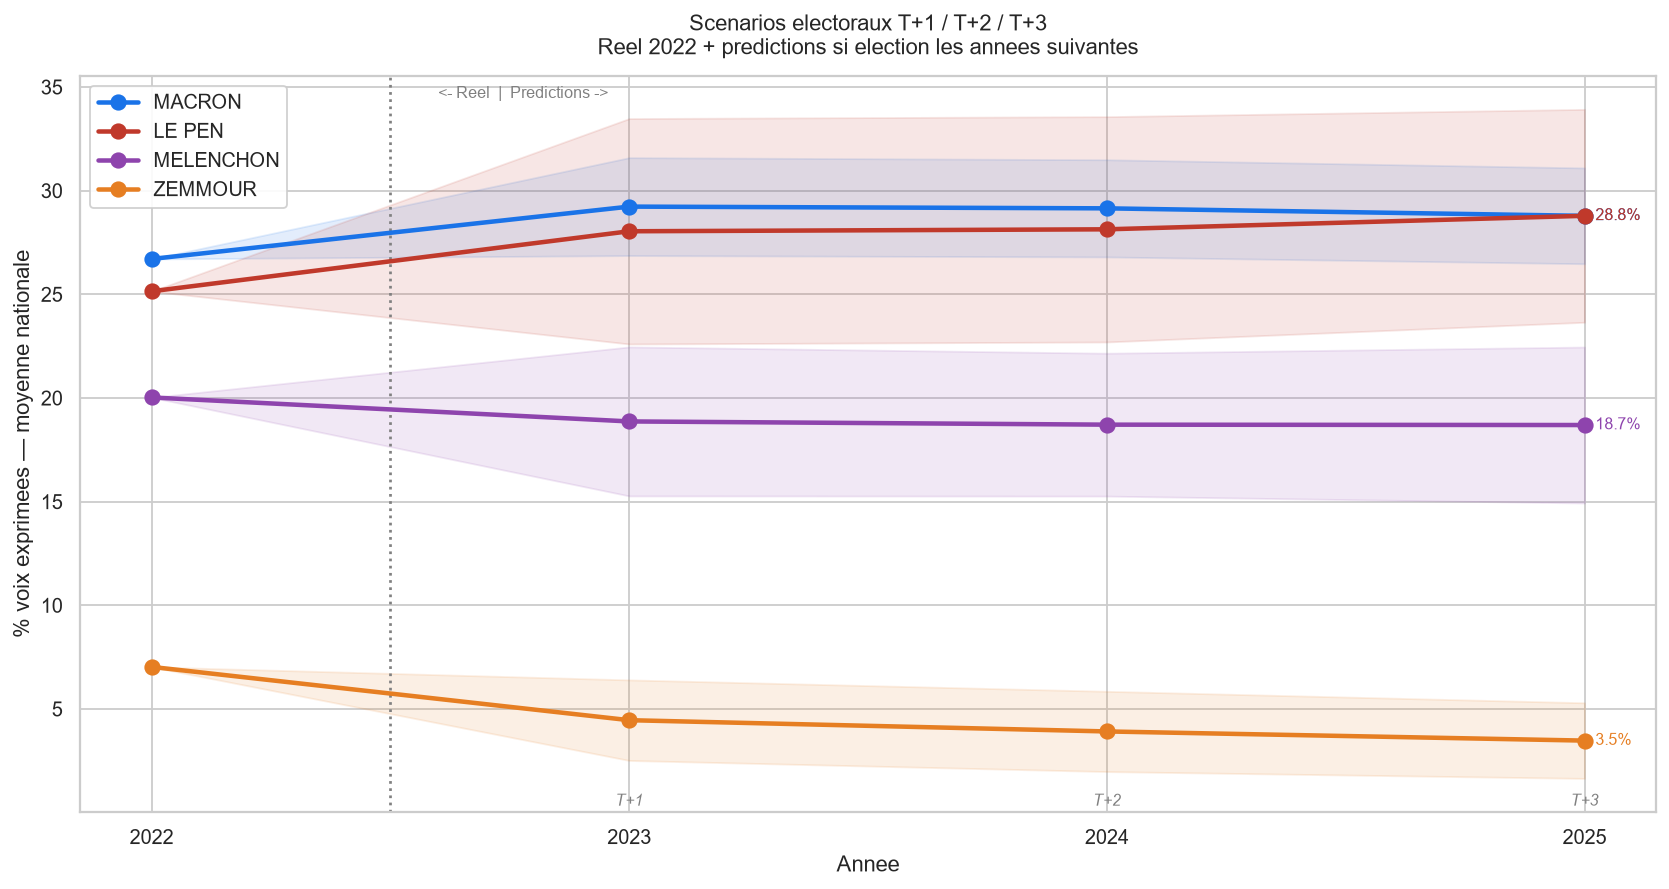

Sauvegarde : viz1_courbe_temporelle.png


In [15]:
# Moyenne nationale + ecart-type par annee
stats_pred = (df_pred.groupby(['candidat','annee'])['pct_predit']
              .agg(['mean','std']).reset_index())

fig, ax = plt.subplots(figsize=(13,7))

for cand in CANDS:
    col  = COLORS[cand]
    # Point de reference T=0 (election 2022 reelle)
    v0   = scores_2022[cand]
    sub  = stats_pred[stats_pred['candidat']==cand].sort_values('annee')
    yrs  = [2022]+sub['annee'].tolist()
    vals = [v0]+sub['mean'].tolist()
    stds = [0] +sub['std'].tolist()

    # Courbe
    ax.plot(yrs, vals, '-o', color=col, lw=2.5, ms=8, label=cand, zorder=3)

    # Bande d'incertitude (1 sigma)
    ax.fill_between(yrs,
                    [v-s for v,s in zip(vals,stds)],
                    [v+s for v,s in zip(vals,stds)],
                    color=col, alpha=.12, zorder=2)

    # Annotation valeur finale
    ax.annotate(f'{vals[-1]:.1f}%',
                xy=(yrs[-1], vals[-1]), xytext=(6,0),
                textcoords='offset points', color=col, fontsize=9, va='center')

# Separateur reel / prediction
ax.axvline(2022.5, color='gray', ls=':', lw=1.5)
ax.text(2022.6, ax.get_ylim()[1]*0.97, '<- Reel  |  Predictions ->',
        color='gray', fontsize=9)

# Etiquettes des horizons
for yr, label in zip([2023,2024,2025], ['T+1','T+2','T+3']):
    ax.text(yr, ax.get_ylim()[0]+0.3, label, ha='center',
            fontsize=9, color='gray', style='italic')

ax.set_xticks([2022,2023,2024,2025])
ax.set_xlabel('Annee')
ax.set_ylabel('% voix exprimees — moyenne nationale')
ax.set_title('Scenarios electoraux T+1 / T+2 / T+3\n'
             'Reel 2022 + predictions si election les annees suivantes', pad=12)
ax.legend(loc='upper left', framealpha=.9)

plt.tight_layout()
plt.savefig('viz1_courbe_temporelle.png', dpi=150)
plt.show()
print('Sauvegarde : viz1_courbe_temporelle.png')

## 8. Visualisation 2 — Heatmap des scores predits (T+3 = 2025)

Tableau croise **departements x candidats**, trie par score LE PEN decroissant  
(proxy classique du vote protestataire territorial).

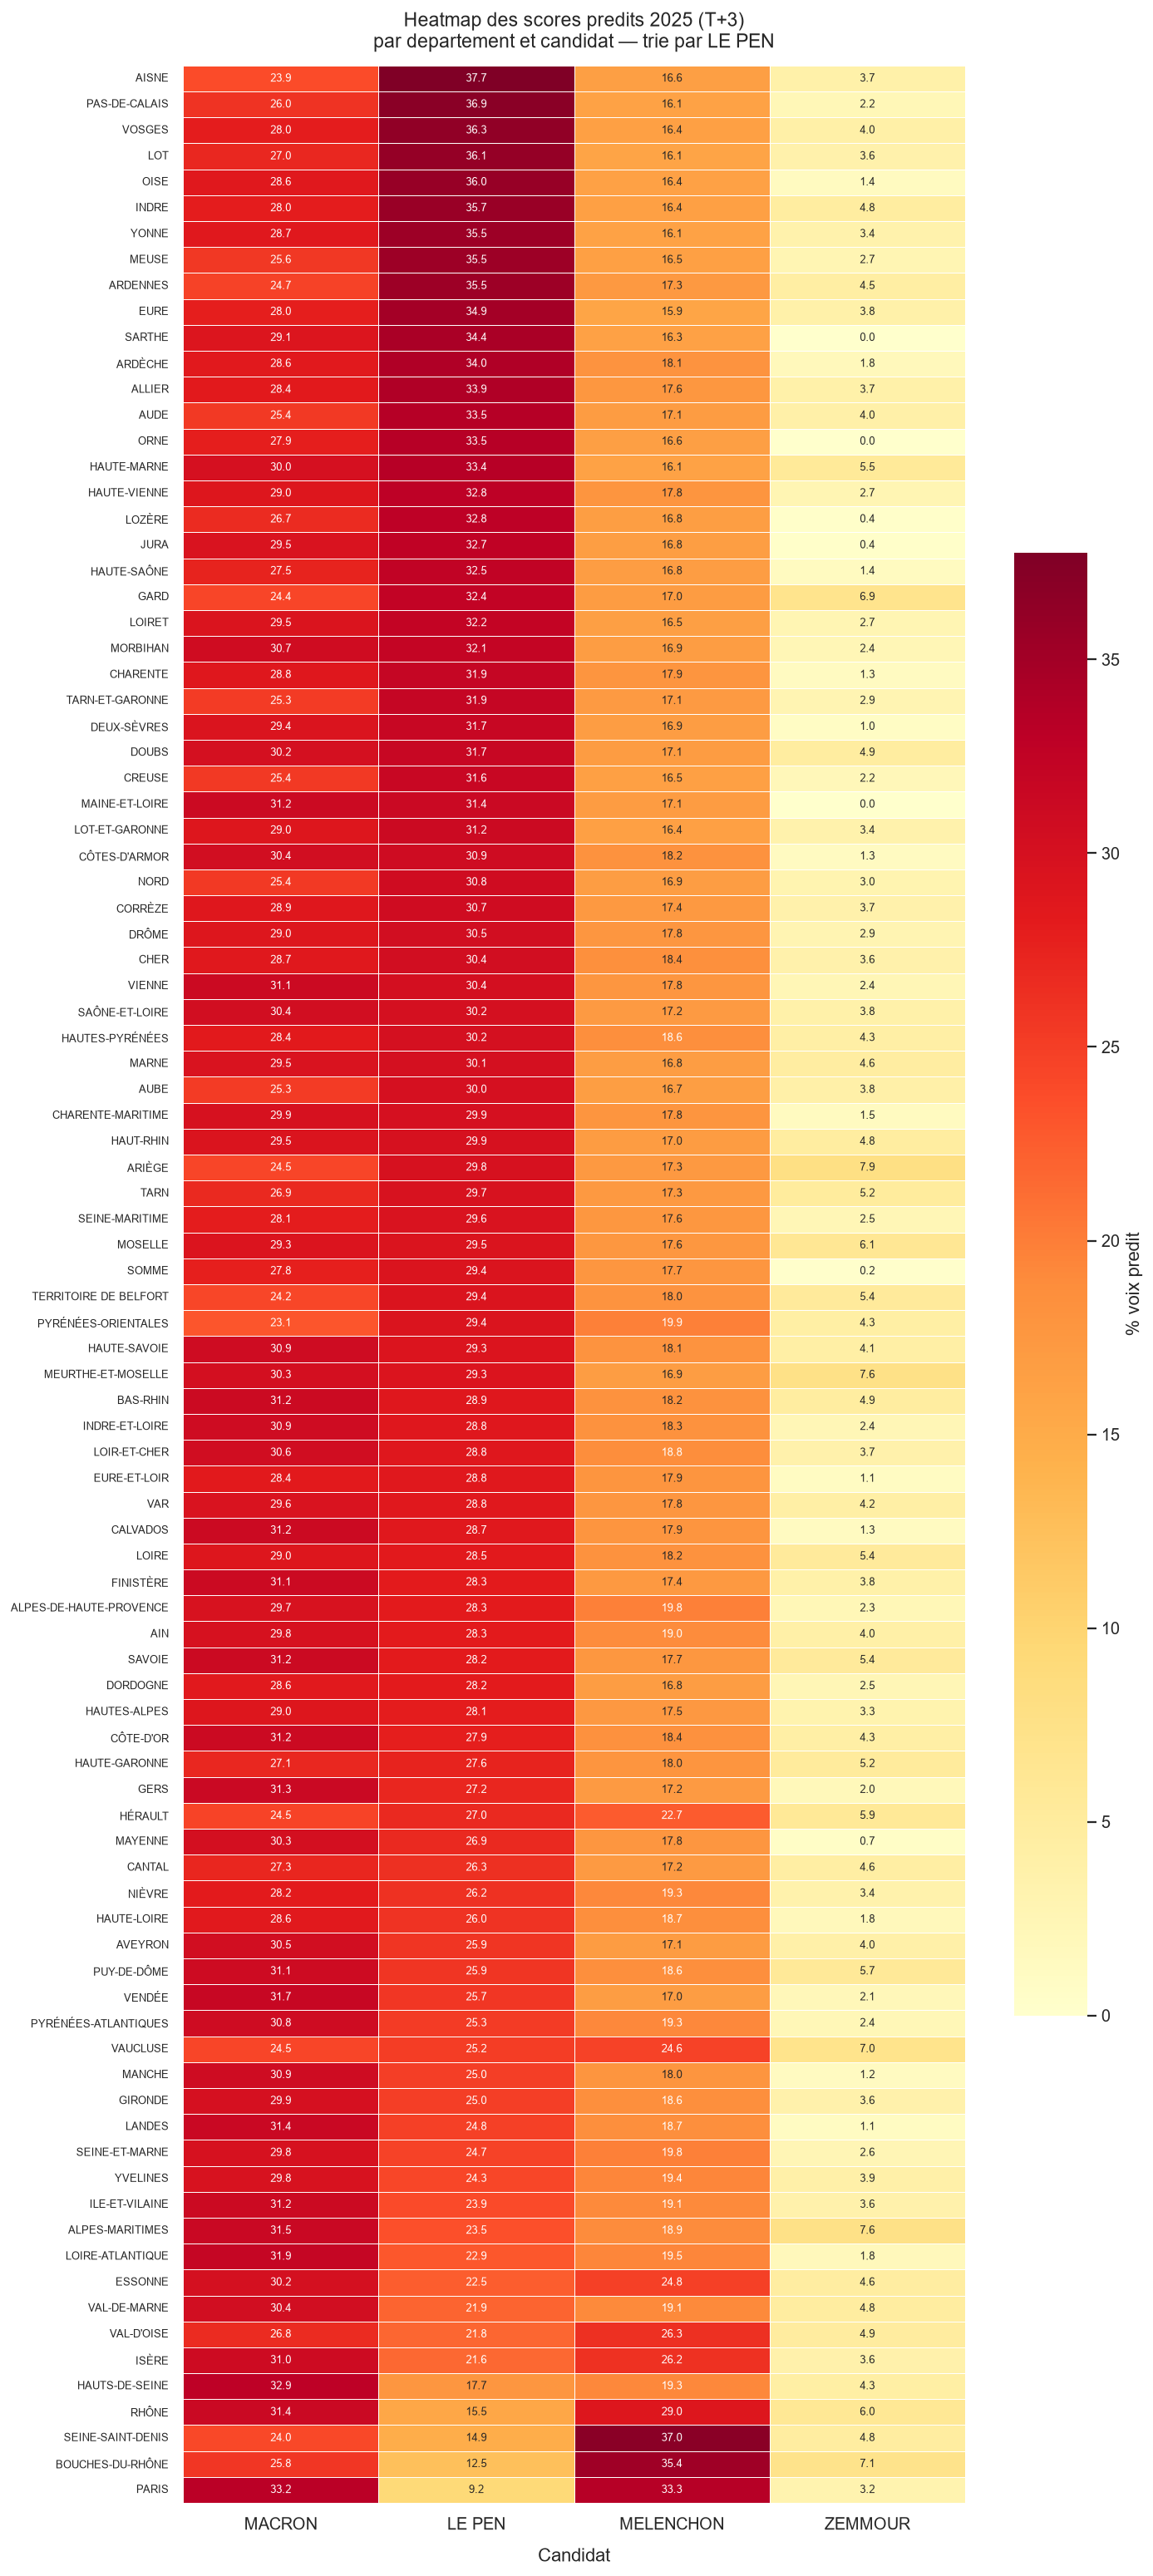

Sauvegarde : viz2_heatmap_depts.png


In [16]:
df_hm = (df_pred[df_pred['annee']==2025]
         .pivot_table(index='libelle_dept', columns='candidat', values='pct_predit')
         [CANDS]
         .sort_values('LE PEN', ascending=False))

fig, ax = plt.subplots(figsize=(11, 24))
sns.heatmap(
    df_hm, annot=True, fmt='.1f',
    cmap='YlOrRd', linewidths=.4,
    cbar_kws={'label':'% voix predit','shrink':.6},
    ax=ax, annot_kws={'size':7}
)
ax.set_title('Heatmap des scores predits 2025 (T+3)\n'
             'par departement et candidat — trie par LE PEN',
             fontsize=13, pad=12)
ax.set_xlabel('Candidat', labelpad=10)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.savefig('viz2_heatmap_depts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegarde : viz2_heatmap_depts.png')

## 9. Visualisation 3 — Diagramme de probabilite / incertitude

Chacun des 200 arbres du Random Forest produit une prediction differente.  
La distribution de ces predictions forme un **diagramme de probabilite** :  
plus la courbe est etroite, plus le modele est confident ; plus elle est large, plus l'incertitude est grande.  
On superpose T+1, T+2, T+3 pour voir si l'incertitude augmente avec l'horizon.

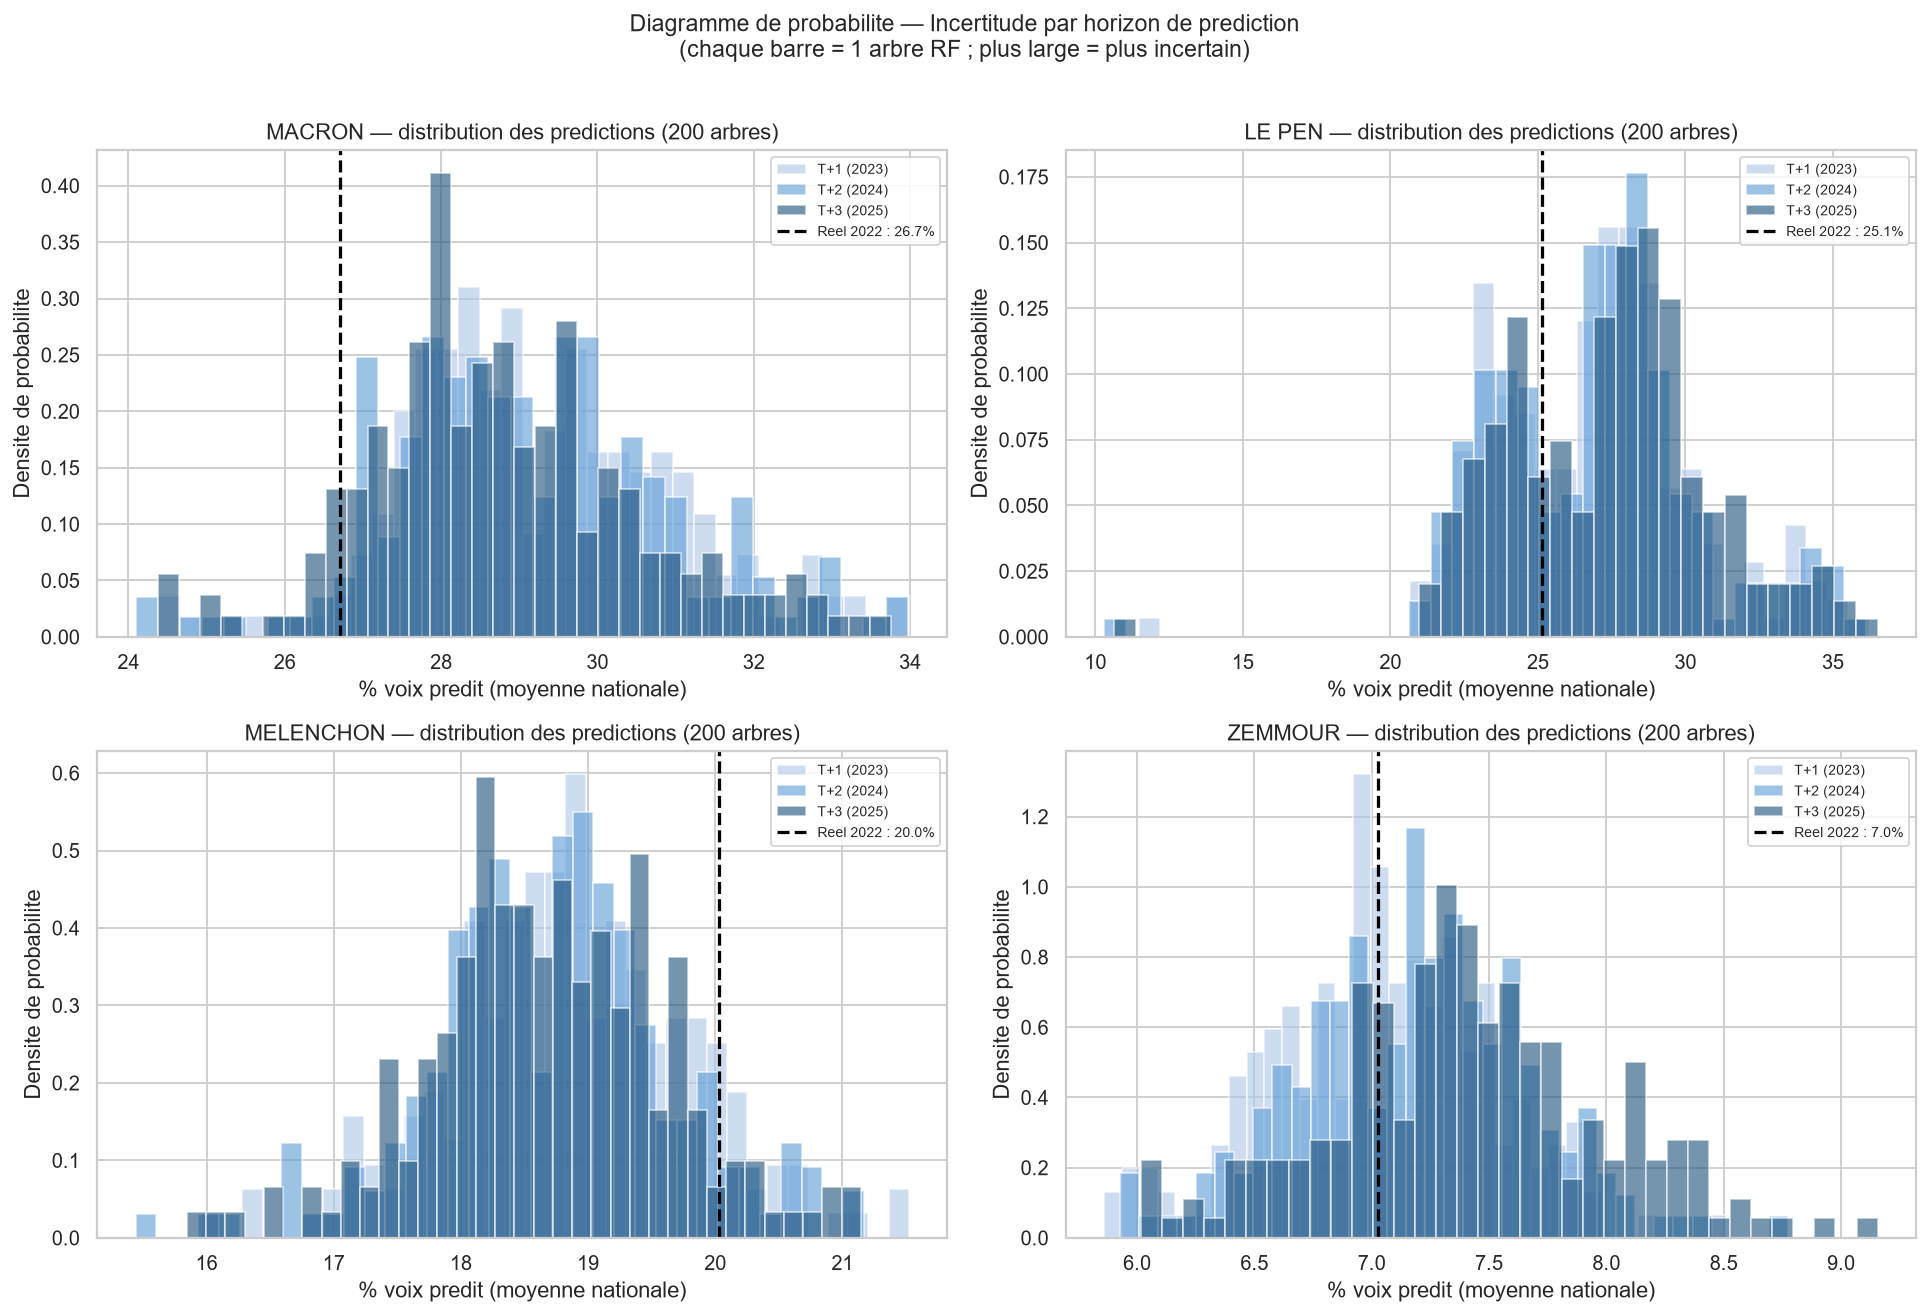

Sauvegarde : viz3_diagramme_probabilite.png


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, cand in enumerate(CANDS):
    ax  = axes[i]
    col = COLORS[cand]
    rf  = rf_models[cand]

    palette_t = ['#aec6e8','#5b9bd5','#1a4f7a']  # bleu clair -> fonce : T+1, T+2, T+3

    for j, (yr, label) in enumerate(zip(ANNEES_PRED, ['T+1 (2023)','T+2 (2024)','T+3 (2025)'])):
        X = feat_pred[yr][FEAT_COLS].fillna(feat_pred[yr][FEAT_COLS].median()).values

        # Prediction de chaque arbre -> distribution nationale
        tree_means = np.array([tree.predict(X).mean() for tree in rf.estimators_])

        ax.hist(tree_means, bins=35, alpha=.60, color=palette_t[j],
                density=True, label=label)

    # Score reel 2022 comme reference
    v0 = scores_2022[cand]
    ax.axvline(v0, color='black', ls='--', lw=1.8, label=f'Reel 2022 : {v0:.1f}%')

    ax.set_title(f'{cand} — distribution des predictions (200 arbres)')
    ax.set_xlabel('% voix predit (moyenne nationale)')
    ax.set_ylabel('Densite de probabilite')
    ax.legend(fontsize=8, framealpha=.85)

plt.suptitle('Diagramme de probabilite — Incertitude par horizon de prediction\n'
             '(chaque barre = 1 arbre RF ; plus large = plus incertain)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('viz3_diagramme_probabilite.png', dpi=150)
plt.show()
print('Sauvegarde : viz3_diagramme_probabilite.png')

## 10. Conclusion et reponses aux questions du sujet

In [18]:
print('='*68)
print('SYNTHESE FINALE — Electio-Analytics POC')
print('='*68)

print('\nACCURACY DES MODELES')
print(f'{"Candidat":<12} {"Modele":<14} {"R2":>6} {"MAE (pts%)":>12} {"RMSE":>7}')
print('-'*55)
for c in CANDS:
    info = best_models[c]
    print(f'{c:<12} {info["nom"]:<14} {info["r2"]:>6.3f} {info["mae"]:>12.2f} {info["rmse"]:>7.2f}')

print('\nPREDICTIONS NATIONALES MOYENNES')
print(f'{"Candidat":<12} {"Reel 2022":>10} {"T+1 2023":>10} {"T+2 2024":>10} {"T+3 2025":>10}')
print('-'*55)
for c in CANDS:
    r = scores_2022[c]
    p = [df_pred[(df_pred.candidat==c)&(df_pred.annee==a)]['pct_predit'].mean()
         for a in ANNEES_PRED]
    print(f'{c:<12} {r:>9.1f}% {p[0]:>9.1f}% {p[1]:>9.1f}% {p[2]:>9.1f}%')

print()
print('REPONSE Q1 — Variable la plus correlee aux resultats electoraux :')
for c in CANDS:
    df_c = datasets[c]
    corrs = df_c[FEAT_COLS].corrwith(df_c['y'])
    best  = corrs.abs().idxmax()
    print(f'  {c:<12} -> {best:<35} r = {corrs[best]:+.3f}')

print()
print('REPONSE Q2 — Apprentissage supervise :')
print('  Un algorithme apprend la fonction f(X)->y sur des exemples labelises')
print('  (X = features socio-eco par dept, y = % voix reels 2022).')
print('  Il generalise cette relation aux annees futures non observees.')

print()
print('REPONSE Q3 — Definition de l\'accuracy :')
print('  R2 = proportion de variance expliquee (0=nul, 1=parfait). Seuil : >0.40.')
print('  MAE = erreur en points de %, lisible sans statistiques. Seuil : <3 pts%.')
print('  Note : les R2 modestes (1 seule election en base) seront ameliores avec')
print('  les scrutins de 2017 et 2012 si Electio-Analytics fournit ces donnees.')
print('='*68)

SYNTHESE FINALE — Electio-Analytics POC

ACCURACY DES MODELES
Candidat     Modele             R2   MAE (pts%)    RMSE
-------------------------------------------------------
MACRON       RandomForest    0.366         2.33    2.93
LE PEN       XGBoost         0.539         2.99    3.92
MELENCHON    RandomForest    0.189         2.45    3.64
ZEMMOUR      Ridge           0.312         0.92    1.15

PREDICTIONS NATIONALES MOYENNES
Candidat      Reel 2022   T+1 2023   T+2 2024   T+3 2025
-------------------------------------------------------
MACRON            26.7%      29.2%      29.1%      28.8%
LE PEN            25.1%      28.0%      28.1%      28.8%
MELENCHON         20.0%      18.9%      18.7%      18.7%
ZEMMOUR            7.0%       4.5%       3.9%       3.5%

REPONSE Q1 — Variable la plus correlee aux resultats electoraux :
  MACRON       -> chomage_moyen                       r = -0.607
  LE PEN       -> crim_vols_sans_violence             r = -0.469
  MELENCHON    -> crim_vols_ave

In [19]:
# Export CSV — livrables 2
df_pred.to_csv('predictions_T1_T2_T3.csv', index=False)
df_feat.to_csv('features_socioeco_agregees.csv', index=False)
print('Exports:')
print('  predictions_T1_T2_T3.csv        — predictions par dept/annee/candidat')
print('  features_socioeco_agregees.csv   — dataset nettoye et normalise')

Exports:
  predictions_T1_T2_T3.csv        — predictions par dept/annee/candidat
  features_socioeco_agregees.csv   — dataset nettoye et normalise


---
*MSPR TPRE813 — EPSI Toulouse 2025/2026 | Donnees : data.gouv.fr*